In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

# DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) predstavlja algoritam za klasterovanje zasnovan na gustini podataka. Za razliku od algoritama kao sto su KMeans ili Agglomerative Clustering, DBSCAN ne zahteva unapred definisan broj klastera i sposoban je da automatski prepozna sum i izdvojene instance.

Osnovna ideja algoritma jeste da tacke koje se nalaze u dovoljno gustim regionima pripadaju istom klasteru, dok se tacke koje nemaju dovoljno suseda oznacavaju kao sum.

DBSCAN koristi dva kljucna parametra:

- **eps** – maksimalno rastojanje izmedju dve tacke kako bi se smatrale susedima
- **min_samples** – minimalan broj susednih tacaka potreban da bi se formirao gust region

Na osnovu ovih parametara svaka instanca moze biti klasifikovana kao:

- **Core point** – tacka koja ima najmanje `min_samples` suseda unutar rastojanja `eps`
- **Border point** – tacka koja nema dovoljan broj suseda da bude jezgro klastera, ali se nalazi u blizini neke core tacke
- **Noise point** – tacka koja ne pripada nijednom klasteru i smatra se sumom

Proces klasterovanja zapocinje izborom jedne core tacke. Zatim se klaster prosiruje ukljucivanjem svih gustinski povezanih tacaka. Ovaj postupak se ponavlja sve dok se ne obrade sve instance u skupu podataka.

Glavne prednosti DBSCAN algoritma su:

- nije potrebno unapred zadati broj klastera,
- prirodno identifikuje sum i atipicne instance,
- sposoban je da pronadje klastere proizvoljnog oblika.

Sa druge strane, kvalitet rezultata znacajno zavisi od izbora parametara `eps` i `min_samples`, zbog cega ce u nastavku biti analiziran veci broj njihovih kombinacija.

In [2]:
X_scaled = pd.read_csv("../../data/data_full_scaled.csv")

In [3]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

In [4]:
from sklearn.decomposition import PCA
import numpy as np

components_list = range(3, 11)

sample_size = min(10000, X_scaled.shape[0])
random_state = 42

sample_idx = np.random.RandomState(random_state).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

pca_samples = {}

for n_components in components_list:
    
    pca = PCA(
        n_components=n_components,
        random_state=random_state
    )
    
    X_pca = pca.fit_transform(X_scaled)
    X_pca_sample = X_pca[sample_idx]
    
    pca_samples[f"pca_{n_components}"] = {
        "X": X_pca_sample,
        "explained_variance": pca.explained_variance_ratio_.sum()
    }

for name, data in pca_samples.items():
    print(name, data["X"].shape, data["explained_variance"])

pca_3 (10000, 3) 0.026899382924845793
pca_4 (10000, 4) 0.03250708990382471
pca_5 (10000, 5) 0.038035595232920015
pca_6 (10000, 6) 0.043419657519138795
pca_7 (10000, 7) 0.04869702627975456
pca_8 (10000, 8) 0.053797300757677094
pca_9 (10000, 9) 0.0588662247066292
pca_10 (10000, 10) 0.06390887615478556


### Analiza DBSCAN rezultata

U ovom koraku testirane su razlicite kombinacije parametara `eps` i `min_samples` nad PCA reprezentacijama sa 3 do 10 komponenti.

Najbolji rezultati prema Silhouette Score pokazatelju dobijeni su za manji broj PCA komponenti, posebno za **PCA-3** i **PCA-4**. Najvisa vrednost iznosi **0.408**, za konfiguraciju **PCA-3, eps = 1.0, min_samples = 50**.

Medjutim, i kod DBSCAN algoritma uocava se da vecina najboljih konfiguracija formira samo **2 klastera**, pri cemu je jedan klaster znatno veci od drugog. Procenat suma je uglavnom nizak, sto znaci da algoritam vecinu instanci uspeva da dodeli nekom klasteru.

Iako DBSCAN ostvaruje relativno dobar Silhouette Score, potrebno je dodatno proveriti raspodelu klastera i njihovu interpretabilnost, jer visok skor ne mora nuzno znaciti da su dobijene grupe korisne za dalju analizu.

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 20, 50]

dbscan_results = []

for pca_name, data in pca_samples.items():
    
    X = data["X"]
    explained_variance = data["explained_variance"]
    
    for eps in eps_values:
        
        for min_samples in min_samples_values:
            
            model = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )
            
            labels = model.fit_predict(X)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_pct = np.mean(labels == -1) * 100
            
            if n_clusters >= 2:
                silhouette = silhouette_score(X, labels)
            else:
                silhouette = np.nan
            
            cluster_sizes = pd.Series(labels).value_counts()
            
            dbscan_results.append({
                "pca": pca_name,
                "n_components": int(pca_name.split("_")[1]),
                "explained_variance": explained_variance,
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_pct": noise_pct,
                "silhouette": silhouette,
                "min_cluster_size": cluster_sizes[cluster_sizes.index != -1].min() if n_clusters > 0 else 0,
                "max_cluster_size": cluster_sizes[cluster_sizes.index != -1].max() if n_clusters > 0 else 0
            })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca,n_components,explained_variance,eps,min_samples,n_clusters,noise_pct,silhouette,min_cluster_size,max_cluster_size
15,pca_3,3,0.026899,1.0,50,2,0.87,0.408417,154,9759
51,pca_4,4,0.032507,1.5,50,2,0.25,0.400145,91,9884
10,pca_3,3,0.026899,0.7,20,2,1.57,0.374241,163,9680
44,pca_4,4,0.032507,1.0,5,2,0.31,0.365883,106,9863
83,pca_5,5,0.038036,1.5,50,2,0.44,0.357490,89,9867
45,pca_4,4,0.032507,1.0,10,2,0.53,0.352530,105,9842
5,pca_3,3,0.026899,0.5,10,2,3.04,0.349507,153,9543
46,pca_4,4,0.032507,1.0,20,3,1.14,0.345087,70,9726
11,pca_3,3,0.026899,0.7,50,2,5.31,0.342609,98,9371
8,pca_3,3,0.026899,0.7,5,2,0.32,0.325592,5,9963


Nakon eliminacije konfiguracija sa vise od 30% suma, analizirane su preostale kombinacije parametara. Najbolje rezultate ostvaruju PCA reprezentacije sa 3 do 5 komponenti, pri cemu Silhouette Score dostize vrednosti iznad 0.40.

Posebno se izdvaja konfiguracija sa 3 PCA komponente, `eps = 1.0` i `min_samples = 50`, koja ostvaruje najbolji rezultat uz veoma mali procenat suma i formira dva jasno definisana klastera.

In [6]:
dbscan_results[
    (dbscan_results["n_clusters"] >= 2) &
    (dbscan_results["noise_pct"] <= 30)
].sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca,n_components,explained_variance,eps,min_samples,n_clusters,noise_pct,silhouette,min_cluster_size,max_cluster_size
15,pca_3,3,0.026899,1.0,50,2,0.87,0.408417,154,9759
51,pca_4,4,0.032507,1.5,50,2,0.25,0.400145,91,9884
10,pca_3,3,0.026899,0.7,20,2,1.57,0.374241,163,9680
44,pca_4,4,0.032507,1.0,5,2,0.31,0.365883,106,9863
83,pca_5,5,0.038036,1.5,50,2,0.44,0.357490,89,9867
45,pca_4,4,0.032507,1.0,10,2,0.53,0.352530,105,9842
5,pca_3,3,0.026899,0.5,10,2,3.04,0.349507,153,9543
46,pca_4,4,0.032507,1.0,20,3,1.14,0.345087,70,9726
11,pca_3,3,0.026899,0.7,50,2,5.31,0.342609,98,9371
8,pca_3,3,0.026899,0.7,5,2,0.32,0.325592,5,9963


In [7]:
top5_dbscan = (
    dbscan_results
    .sort_values("silhouette", ascending=False)
    .head(5)
)

top5_dbscan

,pca,n_components,explained_variance,eps,min_samples,n_clusters,noise_pct,silhouette,min_cluster_size,max_cluster_size
15,pca_3,3,0.026899,1.0,50,2,0.87,0.408417,154,9759
51,pca_4,4,0.032507,1.5,50,2,0.25,0.400145,91,9884
10,pca_3,3,0.026899,0.7,20,2,1.57,0.374241,163,9680
44,pca_4,4,0.032507,1.0,5,2,0.31,0.365883,106,9863
83,pca_5,5,0.038036,1.5,50,2,0.44,0.357490,89,9867


In [8]:
from sklearn.cluster import DBSCAN

dbscan_models = {}
dbscan_labels = {}

for idx, row in top5_dbscan.iterrows():

    pca_name = row["pca"]

    model = DBSCAN(
        eps=row["eps"],
        min_samples=int(row["min_samples"])
    )

    labels = model.fit_predict(
        pca_samples[pca_name]["X"]
    )

    dbscan_models[idx] = model
    dbscan_labels[idx] = labels

    print(f"\nModel {idx}")
    print(
        f"{pca_name}, eps={row['eps']}, "
        f"min_samples={int(row['min_samples'])}"
    )

    print(
        pd.Series(labels)
        .value_counts(normalize=True)
        .sort_index() * 100
    )


Model 15
pca_3, eps=1.0, min_samples=50
-1     0.87
 0    97.59
 1     1.54
Name: proportion, dtype: float64

Model 51
pca_4, eps=1.5, min_samples=50
-1     0.25
 0    98.84
 1     0.91
Name: proportion, dtype: float64

Model 10
pca_3, eps=0.7, min_samples=20
-1     1.57
 0    96.80
 1     1.63
Name: proportion, dtype: float64

Model 44
pca_4, eps=1.0, min_samples=5
-1     0.31
 0    98.63
 1     1.06
Name: proportion, dtype: float64

Model 83
pca_5, eps=1.5, min_samples=50
-1     0.44
 0    98.67
 1     0.89
Name: proportion, dtype: float64


In [9]:
best_idx = top5_dbscan.index[0]

best_row = top5_dbscan.loc[best_idx]

best_dbscan_labels = dbscan_labels[best_idx]

X_best_dbscan = pca_samples[
    best_row["pca"]
]["X"]

best_eps = best_row["eps"]
best_min_samples = int(best_row["min_samples"])
best_n_components = int(best_row["n_components"])

### Vizuelizacija modela

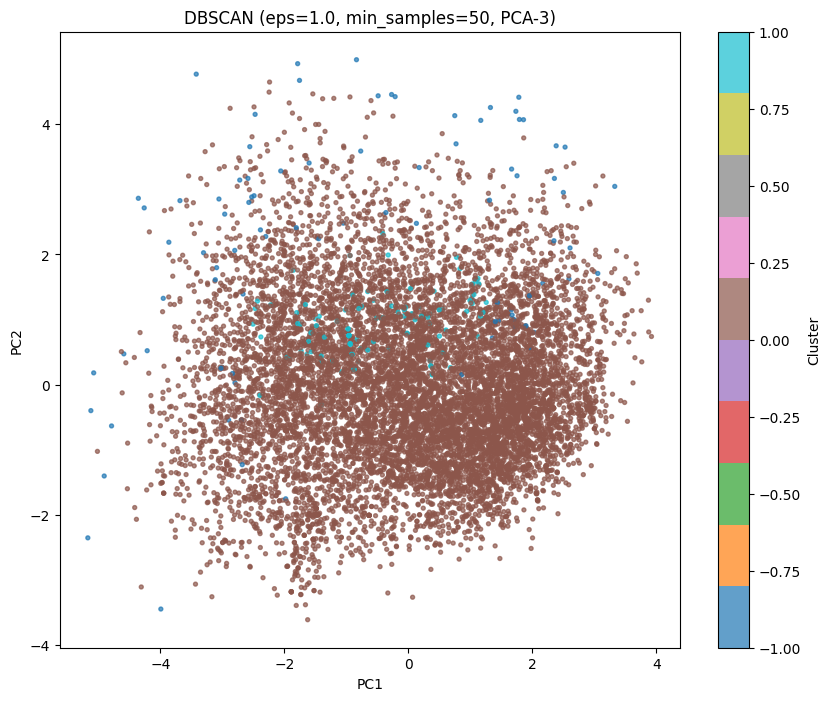

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_best_dbscan[:, 0],
    X_best_dbscan[:, 1],
    c=best_dbscan_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title(
    f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}, PCA-{best_n_components})"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Cluster")

plt.show()

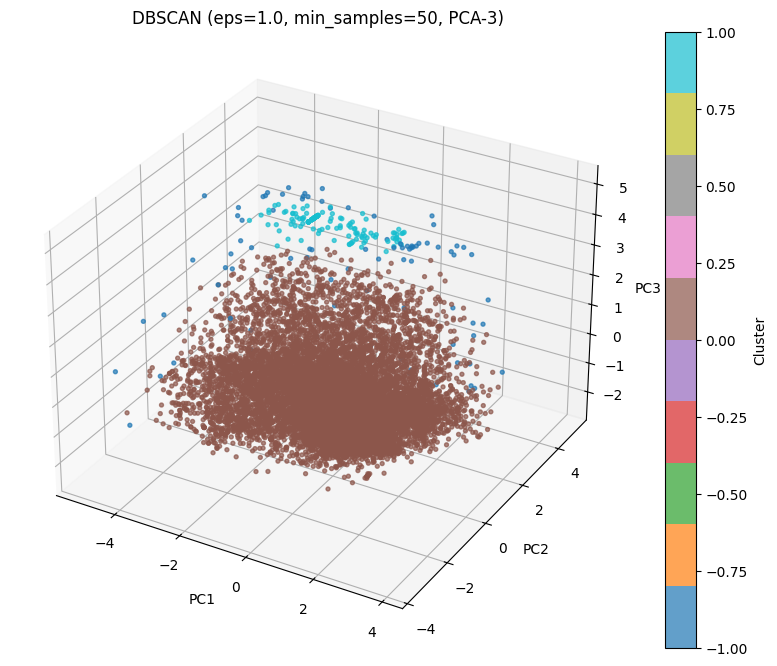

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_best_dbscan[:, 0],
    X_best_dbscan[:, 1],
    X_best_dbscan[:, 2],
    c=best_dbscan_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

ax.set_title(
    f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}, PCA-{best_n_components})"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, label="Cluster")

plt.show()

## DBSCAN Analiza

Nakon analize algoritama KMeans i Agglomerative Clustering, testiran je i DBSCAN algoritam nad PCA reprezentacijama sa 3 do 10 komponenti. Za svaku reprezentaciju ispitane su razlicite kombinacije parametara `eps` i `min_samples`, a kvalitet klasterovanja procenjivan je pomocu Silhouette Score metrike.

Na prvi pogled, DBSCAN je ostvario najbolje rezultate od svih do tada testiranih algoritama. Najbolja konfiguracija ostvarila je Silhouette Score vrednost od 0.408, sto je znacajno vise od rezultata ostvarenih pomocu KMeans i Agglomerative Clustering algoritama.

Medjutim, detaljnija analiza pokazala je da visoka vrednost Silhouette Score metrike nije posledica kvalitetne segmentacije podataka. Najbolji DBSCAN modeli formirali su jedan dominantan klaster koji je sadrzao izmedju 96% i 99% svih instanci, dok su preostale instance bile rasporedjene u veoma male klastere ili oznacene kao sum.

Primer raspodele klastera za najbolju konfiguraciju:

- Klaster 0: 97.59%
- Klaster 1: 1.54%
- Sum: 0.87%

Slicna raspodela primecena je i kod ostalih konfiguracija sa visokim Silhouette Score vrednostima.

Ovakvo ponasanje ukazuje da DBSCAN nije pronasao vise smislenih segmenata oglasa, vec je uglavnom identifikovao jednu veliku grupu slicnih instanci i mali broj izdvojenih primera. Zbog toga se dobijeni rezultat moze posmatrati vise kao detekcija anomalija nego kao segmentacija podataka.

Visoka vrednost Silhouette Score metrike u ovom slucaju nastaje zato sto su mali klasteri veoma udaljeni od dominantnog klastera, sto povecava prosecnu separaciju izmedju grupa. Iako to dovodi do visokog numerickog rezultata, takvo resenje nema veliku prakticnu vrednost za analizu i interpretaciju segmenata oglasa.

Na osnovu toga zakljuceno je da DBSCAN nije pogodan za zadati skup podataka. Za razliku od njega, KMeans i Agglomerative Clustering formirali su uravnotezenije i interpretabilnije klastere, zbog cega su zadrzani kao glavni kandidati za dalju analizu.

### Zakljucak

Iako je DBSCAN ostvario najvise Silhouette Score vrednosti medju testiranim algoritmima, analiza strukture dobijenih klastera pokazala je da model ne vrsi smislenu segmentaciju oglasa. Dominacija jednog veoma velikog klastera i prisustvo samo nekoliko malih grupa ukazuju da algoritam prepoznaje anomalije i retke primere, a ne prirodne segmente unutar podataka. **Zbog toga DBSCAN nije ukljucen medju finalne modele za poredjenje**.